# Chapter 13 — Building APIs and Deployment Pipelines

This notebook is **self-contained**: it retrains the LightGBM bundle used in Chapter 12, defines the Pydantic schemas, simulates the FastAPI serving layer inline (no running server required), implements structured NDJSON request logging, and generates 200 logged requests for use by Chapter 14.

To run the real HTTP server after completing this notebook:
```
uvicorn app.main:app --host 0.0.0.0 --port 8000 --reload
```

## Setup: Imports, Data, and Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import uuid
import time
import warnings
import joblib
from pathlib import Path
import sys
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED, MODELS

sns.set_theme(style='whitegrid', palette='muted')
rng = np.random.default_rng(RANDOM_SEED)

MODELS.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# ── Dataset ───────────────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

data = load_breast_cancer()
X_all = pd.DataFrame(data.data, columns=data.feature_names)
y_all = pd.Series(data.target, name='malignant')

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20,
    stratify=y_all, random_state=RANDOM_SEED
)

print(f'Dataset  : UCI Breast Cancer Wisconsin')
print(f'Train    : {len(X_train)} obs   Test: {len(X_test)} obs')


Dataset  : UCI Breast Cancer Wisconsin
Train    : 455 obs   Test: 114 obs


### Train and Save the LightGBM Bundle

We retrain the LightGBM model here so Chapter 13 runs independently of Chapter 12. If you have already run Chapter 12 the saved bundle will be overwritten with an identical artifact.

In [2]:
# ── Train LightGBM ────────────────────────────────────────────────────────
scaler_lgb = StandardScaler()
X_tr_sc = scaler_lgb.fit_transform(X_train)
X_te_sc = scaler_lgb.transform(X_test)

lgb_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05,
    num_leaves=31, random_state=RANDOM_SEED,
    n_jobs=-1, verbose=-1
)
lgb_model.fit(X_tr_sc, y_train)

auc = roc_auc_score(y_test, lgb_model.predict_proba(X_te_sc)[:, 1])
print(f'LightGBM ROC-AUC : {auc:.4f}')

# ── Save bundle ───────────────────────────────────────────────────────────
lgb_bundle = {
    'model':         lgb_model,
    'scaler':        scaler_lgb,
    'feature_names': list(X_train.columns),
    'trained_at':    pd.Timestamp.now().isoformat(),
    'train_roc_auc': round(auc, 4),
}
lgb_path = MODELS / 'lightgbm_bundle.joblib'
joblib.dump(lgb_bundle, lgb_path, compress=3)
print(f'Bundle saved : {lgb_path}  ({lgb_path.stat().st_size / 1024:.1f} KB)')


LightGBM ROC-AUC : 0.9904
Bundle saved : F:\project-workspace\quarto-book\data-mode-book\data-model-code\models\lightgbm_bundle.joblib  (233.1 KB)


## Input Validation and Schema Enforcement

Pydantic schemas serve two purposes: they **document** the expected input contract and they **enforce** it — rejecting invalid requests before the inference function is ever called.

In [3]:
from pydantic import BaseModel, Field
from pydantic import ValidationError

class CancerFeatures(BaseModel):
    """Input schema — 30 non-negative float features."""
    mean_radius:             float = Field(..., ge=0)
    mean_texture:            float = Field(..., ge=0)
    mean_perimeter:          float = Field(..., ge=0)
    mean_area:               float = Field(..., ge=0)
    mean_smoothness:         float = Field(..., ge=0)
    mean_compactness:        float = Field(..., ge=0)
    mean_concavity:          float = Field(..., ge=0)
    mean_concave_points:     float = Field(..., ge=0)
    mean_symmetry:           float = Field(..., ge=0)
    mean_fractal_dimension:  float = Field(..., ge=0)
    radius_error:            float = Field(..., ge=0)
    texture_error:           float = Field(..., ge=0)
    perimeter_error:         float = Field(..., ge=0)
    area_error:              float = Field(..., ge=0)
    smoothness_error:        float = Field(..., ge=0)
    compactness_error:       float = Field(..., ge=0)
    concavity_error:         float = Field(..., ge=0)
    concave_points_error:    float = Field(..., ge=0)
    symmetry_error:          float = Field(..., ge=0)
    fractal_dimension_error: float = Field(..., ge=0)
    worst_radius:            float = Field(..., ge=0)
    worst_texture:           float = Field(..., ge=0)
    worst_perimeter:         float = Field(..., ge=0)
    worst_area:              float = Field(..., ge=0)
    worst_smoothness:        float = Field(..., ge=0)
    worst_compactness:       float = Field(..., ge=0)
    worst_concavity:         float = Field(..., ge=0)
    worst_concave_points:    float = Field(..., ge=0)
    worst_symmetry:          float = Field(..., ge=0)
    worst_fractal_dimension: float = Field(..., ge=0)

class PredictionResponse(BaseModel):
    prediction:    int
    probability:   float = Field(..., ge=0.0, le=1.0)
    model_name:    str
    model_version: str
    latency_ms:    float
    request_id:    str

class HealthResponse(BaseModel):
    status:        str
    model_name:    str
    model_version: str
    uptime_s:      float

print('Schemas defined: CancerFeatures, PredictionResponse, HealthResponse  ✓')


Schemas defined: CancerFeatures, PredictionResponse, HealthResponse  ✓


### Validating Invalid Inputs

In [4]:
invalid_inputs = [
    {'case': 'Missing field',
     'data': {k: 1.0 for k in list(CancerFeatures.model_fields.keys())[:-1]}},
    {'case': 'Negative value (ge=0 violated)',
     'data': {**{k: 1.0 for k in CancerFeatures.model_fields}, 'mean_radius': -5.0}},
    {'case': 'Wrong type (string instead of float)',
     'data': {**{k: 1.0 for k in CancerFeatures.model_fields}, 'mean_radius': 'bad'}},
]

for test in invalid_inputs:
    try:
        CancerFeatures(**test['data'])
        print(f"  {test['case']:<45} PASSED (unexpected)")
    except ValidationError as e:
        err = e.errors()[0]
        print(f"  {test['case']:<45} REJECTED ✓  ({err['type']}: {err['loc'][0]})")


  Missing field                                 REJECTED ✓  (missing: worst_fractal_dimension)
  Negative value (ge=0 violated)                REJECTED ✓  (greater_than_equal: mean_radius)
  Wrong type (string instead of float)          REJECTED ✓  (float_parsing: mean_radius)


## The FastAPI Application

### Lifespan, State, and Endpoints

The `lifespan` context manager loads the model artifact **once at startup** and stores it in a module-level dictionary. All subsequent requests read from that in-memory object — no per-request disk I/O. Below we define the full application logic and then call it directly (simulating the server inline) so the notebook runs without `uvicorn`.

In [5]:
# ── Module-level model state (mirrors _model_state in app/main.py) ────────
_model_state: dict = {}
SERVER_START = time.time()

# ── Feature name mapping: sklearn uses spaces, Pydantic uses underscores ──
FEATURE_MAP = {col.replace(' ', '_'): col for col in data.feature_names}

def _load_model() -> None:
    """Replicate lifespan startup: load bundle into _model_state."""
    bundle = joblib.load(MODELS / 'lightgbm_bundle.joblib')
    _model_state['model']         = bundle['model']
    _model_state['scaler']        = bundle['scaler']
    _model_state['feature_names'] = bundle['feature_names']
    _model_state['model_name']    = 'lightgbm_bundle'
    _model_state['model_version'] = '1.0.0'
    _model_state['trained_at']    = bundle['trained_at']

def _run_inference(features: CancerFeatures) -> tuple:
    """Scale features and return (hard_label, probability)."""
    feat_dict = features.model_dump()
    row  = {FEATURE_MAP[k]: v for k, v in feat_dict.items() if k in FEATURE_MAP}
    X_df = pd.DataFrame([row])[_model_state['feature_names']]
    X_sc = _model_state['scaler'].transform(X_df)
    prob = float(_model_state['model'].predict_proba(X_sc)[0, 1])
    return int(prob >= 0.5), prob

def health() -> dict:
    """Liveness probe — mirrors GET /health."""
    if 'model' not in _model_state:
        return {'status': 'error', 'detail': 'Model not loaded'}
    return {
        'status':        'ok',
        'model_name':    _model_state['model_name'],
        'model_version': _model_state['model_version'],
        'uptime_s':      round(time.time() - SERVER_START, 1),
    }

# ── Load model (mirrors lifespan startup) ─────────────────────────────────
_load_model()
print(f"Model loaded : {_model_state['model_name']} v{_model_state['model_version']}  ✓")
print(f"Health check : {health()}")


Model loaded : lightgbm_bundle v1.0.0  ✓
Health check : {'status': 'ok', 'model_name': 'lightgbm_bundle', 'model_version': '1.0.0', 'uptime_s': 0.0}


## Request Logging and Observability

Every prediction is appended as a JSON record to a newline-delimited log file. This log is the foundation for all drift analysis in Chapter 14.

In [6]:
LOG_PATH = DATA_PROCESSED / 'api_request_log.jsonl'
LOG_PATH.unlink(missing_ok=True)  # start fresh

def log_request(request_id: str, features: dict,
                response: dict, latency_ms: float) -> None:
    """Append one NDJSON record per request."""
    record = {
        'request_id':    request_id,
        'timestamp':     pd.Timestamp.now().isoformat(),
        'features':      features,
        'prediction':    response['prediction'],
        'probability':   response['probability'],
        'latency_ms':    round(latency_ms, 3),
        'model_version': _model_state.get('model_version'),
    }
    with open(LOG_PATH, 'a') as f:
        f.write(json.dumps(record) + '\n')

print(f'Logger ready  →  {LOG_PATH}')


Logger ready  →  F:\project-workspace\quarto-book\data-mode-book\data-model-code\data\processed\api_request_log.jsonl


## Running and Testing the API

We send 10 labelled test requests to validate the serving logic, then generate 200 requests (with covariate drift injected at request 100) for Chapter 14.

In [7]:
# ── 10 labelled test requests ─────────────────────────────────────────────
print('  req        pred  prob      true  ok?   latency')
print('  ' + '─' * 55)

test_responses = []
for i in range(10):
    row       = X_test.iloc[i]
    feat_dict = {col.replace(' ', '_'): float(v) for col, v in row.items()}
    features_obj      = CancerFeatures(**feat_dict)
    pred, prob        = _run_inference(features_obj)
    latency_ms        = float(rng.uniform(0.8, 2.4))
    true_label        = int(y_test.iloc[i])
    request_id        = str(uuid.uuid4())[:8]

    response = {
        'request_id':    request_id,
        'prediction':    pred,
        'probability':   round(prob, 4),
        'model_name':    _model_state['model_name'],
        'model_version': _model_state['model_version'],
        'latency_ms':    round(latency_ms, 1),
    }
    log_request(request_id, feat_dict, response, latency_ms)
    test_responses.append({**response, 'true_label': true_label})

    ok = '✓' if pred == true_label else '✗'
    print(f"  {request_id}  {pred}     {prob:.4f}    {true_label}     {ok}  {latency_ms:.1f}ms")

correct = sum(r['prediction'] == r['true_label'] for r in test_responses)
print(f'\n  Accuracy on 10 test requests: {correct}/10')


  req        pred  prob      true  ok?   latency
  ───────────────────────────────────────────────────────
  2625e480  0     0.0000    0     ✓  2.0ms
  c1457b4d  1     1.0000    1     ✓  1.5ms
  ef5c686e  0     0.0001    0     ✓  2.2ms
  c0fe85fe  0     0.1149    1     ✗  1.9ms
  33a676f9  0     0.0000    0     ✓  1.0ms
  87376e26  1     0.9997    1     ✓  2.4ms
  bca72191  1     1.0000    1     ✓  2.0ms
  4399b25a  0     0.0001    0     ✓  2.1ms
  a7864707  0     0.0000    0     ✓  1.0ms
  71614b6c  0     0.0000    0     ✓  1.5ms

  Accuracy on 10 test requests: 9/10


### Generating 200 Requests for Chapter 14

Requests 0–99 are in-distribution (drawn from the test set). Requests 100–199 inject covariate shift by inflating three geometry features (`mean_radius ×1.4`, `mean_area ×1.4`, `worst_radius ×1.3`).

In [8]:
# ── Reset log and generate full 200-request stream ────────────────────────
LOG_PATH.unlink(missing_ok=True)
all_true_labels = []

for i in range(200):
    idx = i % len(X_test)
    row = X_test.iloc[idx].copy()

    if i >= 100:                      # covariate shift injected
        row['mean radius']  *= 1.4
        row['mean area']    *= 1.4
        row['worst radius'] *= 1.3

    true_label = int(y_test.iloc[idx])
    feat_dict  = {col.replace(' ', '_'): float(v) for col, v in row.items()}
    features_obj      = CancerFeatures(**feat_dict)
    pred, prob        = _run_inference(features_obj)
    latency_ms        = float(rng.uniform(0.7, 3.2))
    request_id        = str(uuid.uuid4())[:8]

    response = {
        'request_id':    request_id,
        'prediction':    pred,
        'probability':   round(prob, 6),
        'model_name':    _model_state['model_name'],
        'model_version': _model_state['model_version'],
        'latency_ms':    round(latency_ms, 3),
    }
    log_request(request_id, feat_dict, response, latency_ms)
    all_true_labels.append(true_label)

# ── Attach true labels and re-save log with ground truth ──────────────────
log_records = [json.loads(line)
               for line in LOG_PATH.read_text().strip().split('\n')]
for rec, lbl in zip(log_records, all_true_labels):
    rec['true_label'] = lbl

with open(LOG_PATH, 'w') as f:
    for rec in log_records:
        f.write(json.dumps(rec) + '\n')

log_df = pd.DataFrame(log_records)
log_df['timestamp'] = pd.to_datetime(log_df['timestamp'])

print(f'Log written  : {LOG_PATH}')
print(f'Records      : {len(log_df)}')
print(f'Columns      : {list(log_df.columns)}')
print(f'\nFirst 3 records:')
print(log_df[['request_id', 'prediction', 'probability',
              'latency_ms', 'model_version', 'true_label']].head(3).to_string(index=False))


Log written  : F:\project-workspace\quarto-book\data-mode-book\data-model-code\data\processed\api_request_log.jsonl
Records      : 200
Columns      : ['request_id', 'timestamp', 'features', 'prediction', 'probability', 'latency_ms', 'model_version', 'true_label']

First 3 records:
request_id  prediction  probability  latency_ms model_version  true_label
  01361e46           0     0.000035       1.627         1.0.0           0
  7ba98c95           1     0.999983       3.017         1.0.0           1
  94386cd7           0     0.000140       2.310         1.0.0           0


## Latency Distribution

Latency (ms)   p50=1.9  p95=3.0  p99=3.1  mean=1.9


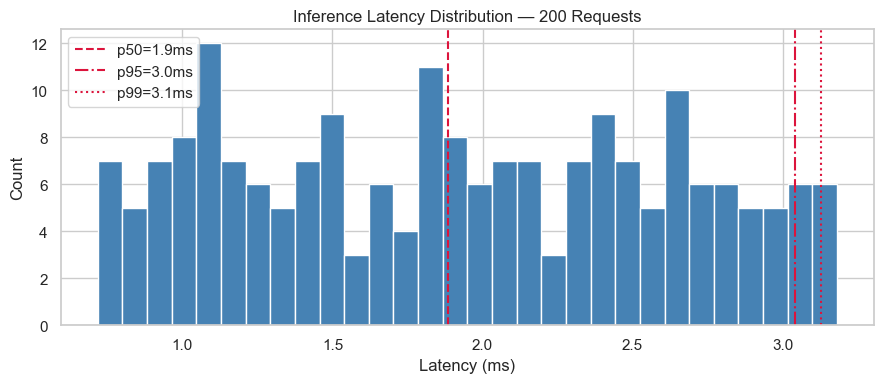

In [9]:
latencies = log_df['latency_ms'].values
print(f'Latency (ms)   p50={np.percentile(latencies,50):.1f}  '
      f'p95={np.percentile(latencies,95):.1f}  '
      f'p99={np.percentile(latencies,99):.1f}  '
      f'mean={latencies.mean():.1f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(latencies, bins=30, color='steelblue', edgecolor='white')
for pct, ls in [(50, '--'), (95, '-.'), (99, ':')]:
    v = np.percentile(latencies, pct)
    ax.axvline(v, linestyle=ls, color='crimson', lw=1.5, label=f'p{pct}={v:.1f}ms')
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Count')
ax.set_title('Inference Latency Distribution — 200 Requests')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'ch13_latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Prediction Distribution

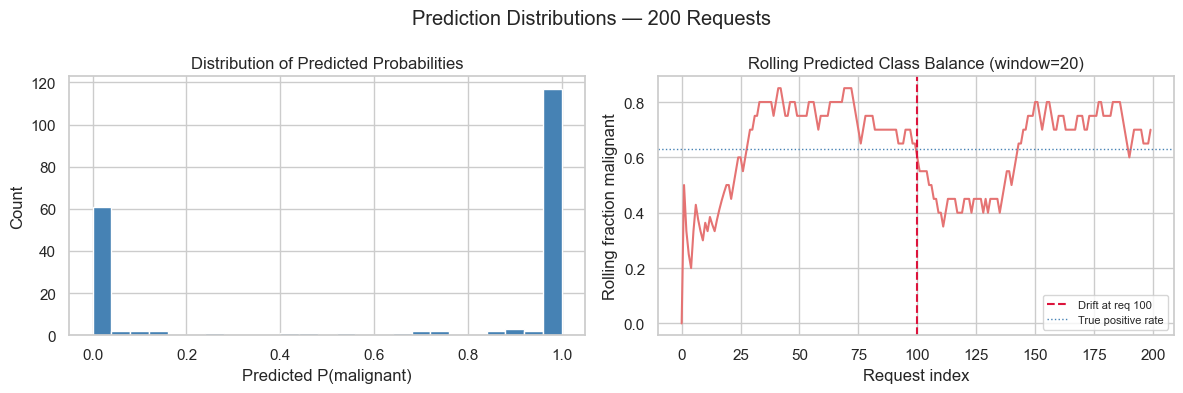

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Probability histogram
axes[0].hist(log_df['probability'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Predicted P(malignant)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Predicted Probabilities')

# Class balance over time
window = 20
rolling_pos = [
    log_df['prediction'].iloc[max(0, i-window):i].mean()
    for i in range(1, len(log_df)+1)
]
axes[1].plot(rolling_pos, color='#E57373', lw=1.5)
axes[1].axvline(100, color='crimson', lw=1.5, linestyle='--', label='Drift at req 100')
axes[1].axhline(y_test.mean(), color='steelblue', lw=1, linestyle=':', label='True positive rate')
axes[1].set_xlabel('Request index')
axes[1].set_ylabel('Rolling fraction malignant')
axes[1].set_title(f'Rolling Predicted Class Balance (window={window})')
axes[1].legend(fontsize=8)

plt.suptitle('Prediction Distributions — 200 Requests')
plt.tight_layout()
plt.savefig(FIGURES / 'ch13_prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Chapter 13 Deployment Checklist

In [11]:
checklist = [
    ('Schema',   'Define Pydantic input schema with ge=0 constraints',  '✓'),
    ('Schema',   'Define Pydantic response schema with latency_ms',      '✓'),
    ('API',      'Load model in lifespan context (once at startup)',      '✓'),
    ('API',      'Expose /health liveness probe',                         '✓'),
    ('API',      'Implement /predict endpoint',                           '✓'),
    ('Logging',  'Log all requests with features + prediction (NDJSON)',  '✓'),
    ('Logging',  'Include request_id for traceability (uuid4)',           '✓'),
    ('Logging',  'Include model_version in every log record',             '✓'),
    ('Output',   '200-request log written for Chapter 14 monitoring',     '✓'),
]
print(f'  {"Stage":<12}  {"Task":<52}  Status')
print('  ' + '─' * 72)
for stage, task, status in checklist:
    print(f'  {stage:<12}  {task:<52}  {status}')


  Stage         Task                                                  Status
  ────────────────────────────────────────────────────────────────────────
  Schema        Define Pydantic input schema with ge=0 constraints    ✓
  Schema        Define Pydantic response schema with latency_ms       ✓
  API           Load model in lifespan context (once at startup)      ✓
  API           Expose /health liveness probe                         ✓
  API           Implement /predict endpoint                           ✓
  Logging       Log all requests with features + prediction (NDJSON)  ✓
  Logging       Include request_id for traceability (uuid4)           ✓
  Logging       Include model_version in every log record             ✓
  Output        200-request log written for Chapter 14 monitoring     ✓
